# Billionaire Statistics Project
##### QMSS 495 FA24
##### By Aileen Gonzalez

## Project Overview

The ["Billionaires Statistics Dataset (2023)" from Kaggle](https://www.kaggle.com/datasets/nelgiriyewithana/billionaires-statistics-dataset/data) provides detailed statistics on the world's billionaires, covering aspects such as wealth, business sectors, industries, and personal demographics. Key features of the dataset include wealth metrics (finalWorth), business information (industries), economic indicators (gdp_country, tax_revenue_country_country), and demographic details (age, selfMade, status).

Project interest stemmed from examining if being "Self Made" influences billionaire status and wealth, whether wealth is concentrated among the richest people, the relationship between billionaire wealth and economic factors, and if wealth creation is limited.

This project specifically hones in on the question **"Can we predict whether a billionaire is self-made or has inherited wealth based on their wealth, age, industry, and country-related factors?"**

This question explores the state of economic upward mobility within the countries with the most billionaires. This analysis sheds light on whether wealth accumulation is driven by effort, innovation, and creativity (self-made) compared to inherited privilege. It also considers the proportion of wealth inequality through revealing how wealth is concentred and passed through generations.

Further questions for analysis, that may utilize different algorithms and non-predictive modeling, include:

* How is wealth distributed among billionaires, and is it concentrated in the hands of a few?
* What percentage of the total wealth is held by the top richest individuals?
* Do billionaires contribute proportionally to national economies, or is wealth hoarded?
* Are most billionaires older, indicating that wealth creation is limited to earlier generations?



### Data Selection: Billionaire Statistics

In [1]:
import pandas as pd

Let's begin by taking a look at some of the information the dataset contains and how we can inform our question by looking at and examining the first five rows.

In [2]:
bill_stats = pd.read_csv('Billionaires Statistics Dataset.csv') # Read in dataset
print(bill_stats.head()) # Show first 5 rows of dataset

   rank  finalWorth               category                personName   age  \
0     1      211000       Fashion & Retail  Bernard Arnault & family  74.0   
1     2      180000             Automotive                 Elon Musk  51.0   
2     3      114000             Technology                Jeff Bezos  59.0   
3     4      107000             Technology             Larry Ellison  78.0   
4     5      106000  Finance & Investments            Warren Buffett  92.0   

         country    city              source             industries  \
0         France   Paris                LVMH       Fashion & Retail   
1  United States  Austin       Tesla, SpaceX             Automotive   
2  United States  Medina              Amazon             Technology   
3  United States   Lanai              Oracle             Technology   
4  United States   Omaha  Berkshire Hathaway  Finance & Investments   

  countryOfCitizenship  ... cpi_change_country           gdp_country  \
0               France  ...     

In [3]:
print(bill_stats.shape) # Get rows and columns of dataset.

(2640, 35)


Let's look in particular what columns we have that help inform Billionaire Statistics.



In [4]:
print(bill_stats.columns) # Show Billionaire Statistics dataset columns

Index(['rank', 'finalWorth', 'category', 'personName', 'age', 'country',
       'city', 'source', 'industries', 'countryOfCitizenship', 'organization',
       'selfMade', 'status', 'gender', 'birthDate', 'lastName', 'firstName',
       'title', 'date', 'state', 'residenceStateRegion', 'birthYear',
       'birthMonth', 'birthDay', 'cpi_country', 'cpi_change_country',
       'gdp_country', 'gross_tertiary_education_enrollment',
       'gross_primary_education_enrollment_country', 'life_expectancy_country',
       'tax_revenue_country_country', 'total_tax_rate_country',
       'population_country', 'latitude_country', 'longitude_country'],
      dtype='object')


Above we note all 35 columns included in the dataset, however, we want to narrow down our focus. In the following data preprocessing section, we begin to pinpoint what columns will help us analyze our question of interest.

## *Data Preprocessing*


In this section, we work on data preprocessing. Narrowing in our columns of interest, we find missing values, address them, encode categorical variables using one-hot encoding and apply feature scaling.

### *Addressing Missing Values*

We want our analysis to be easy to understand and narrowed into what will be of most value to our question. Considering all of our columns noted earlier, let's pinpoint particular ones of interest and focus our analysis on this area.

Let's begin by creating a function that helps us quicky assess whether one of our columns of interest has a missing value, how many, and what data type it is in order to inform us in our imputation approach.

In [5]:
def find_missing(df, columns):
    summary = pd.DataFrame({
        'Column': columns, # our column names
        'Missing Values': [df[col].isna().sum() for col in columns], # count of missing vals in each col
        'Data Type': [df[col].dtype for col in columns] # the data type of the column
    })

    missing_summary = summary[summary['Missing Values'] > 0] # Filter for columns with missing values only

    return missing_summary if not missing_summary.empty else "No missing vals." # return missing values summary or if there are no missing values then return no missing values

In [6]:
interested_cols = [
    "finalWorth", "rank", "age", "selfMade", "status", "category", "country",
    "gdp_country", "tax_revenue_country_country",
    "total_tax_rate_country", "cpi_country", "cpi_change_country"
]

I chose "finalWorth", "rank", "age", "selfMade", "status", "category", "country", "gdp_country", "tax_revenue_country_country", "total_tax_rate_country", "cpi_country", and "cpi_change_country" as my initial columns of interest.

The columns represent:

*   **finalWorth**: The final net worth of the billionaire in U.S. dollars.
*   **rank**: The ranking of the billionaire in terms of wealth.
*   **age**: The age of the billionaire.
*   **selfMade**: Indicates whether the billionaire is self-made (True/False).
*   **status**: "D" represents self-made billionaires (Founders/Entrepreneurs) and "U" indicates inherited or unearned wealth.
*   **category**: The category or industry in which the billionaire's business operates.
*   **country**: The country in which the billionaire resides.
*   **gdp_country**: Gross Domestic Product (GDP) for the billionaire's country.
*   **tax_revenue_country_country**: Tax revenue in the billionaire's country.
*   **total_tax_rate_country**: Total tax rate in the billionaire's country.
*   **cpi_country**: Consumer Price Index (CPI) for the billionaire's country.
*   **cpi_change_country**: CPI change for the billionaire's country.













These columns contain information that may reveal connections between economic development, age, wealth hoarding, and selfMade status within billionaires.

In [7]:
missing_summary = find_missing(bill_stats, interested_cols)
print(missing_summary)

                         Column  Missing Values Data Type
2                           age              65   float64
6                       country              38    object
7                   gdp_country             164    object
8   tax_revenue_country_country             183   float64
9        total_tax_rate_country             182   float64
10                  cpi_country             184   float64
11           cpi_change_country             184   float64


Applying the function to our columns of interest, we note that missing values only exist in the columns age, country, gdp_country, tax_revenue_country_country, total_tax_rate_country, cpi_country, and cpi_change_country.

Let's go ahead and copy our original DataFrame to create a new independent DataFrame with our columns of interest to still preserve the original data.

In [8]:
bill_stats_interested = bill_stats[interested_cols].copy()

This makes it easier to both view and work with our data of interest from now on.

In [9]:
print(bill_stats_interested.head())

   finalWorth  rank   age  selfMade status               category  \
0      211000     1  74.0     False      U       Fashion & Retail   
1      180000     2  51.0      True      D             Automotive   
2      114000     3  59.0      True      D             Technology   
3      107000     4  78.0      True      U             Technology   
4      106000     5  92.0      True      D  Finance & Investments   

         country           gdp_country  tax_revenue_country_country  \
0         France   $2,715,518,274,227                          24.2   
1  United States  $21,427,700,000,000                           9.6   
2  United States  $21,427,700,000,000                           9.6   
3  United States  $21,427,700,000,000                           9.6   
4  United States  $21,427,700,000,000                           9.6   

   total_tax_rate_country  cpi_country  cpi_change_country  
0                    60.7       110.05                 1.1  
1                    36.6       117.

Earlier we saw that, in particular, country and gdp_country are both the only object types with missing values. However, gdp_country can easily be turned into a numerical value. Let's approach this problem first before imputation by removing non-numerical symbols like "$" and commas. Doing this, we can convert gdp_country to a float64 by utilizing .astype(float).

In [10]:
# Clean 'gdp_country' by removing dollar sign and commas
bill_stats_interested['gdp_country'] = bill_stats_interested['gdp_country'].str.replace(',', '').str.replace('$', '').astype(float)

In [11]:
print(bill_stats_interested.head())

   finalWorth  rank   age  selfMade status               category  \
0      211000     1  74.0     False      U       Fashion & Retail   
1      180000     2  51.0      True      D             Automotive   
2      114000     3  59.0      True      D             Technology   
3      107000     4  78.0      True      U             Technology   
4      106000     5  92.0      True      D  Finance & Investments   

         country   gdp_country  tax_revenue_country_country  \
0         France  2.715518e+12                         24.2   
1  United States  2.142770e+13                          9.6   
2  United States  2.142770e+13                          9.6   
3  United States  2.142770e+13                          9.6   
4  United States  2.142770e+13                          9.6   

   total_tax_rate_country  cpi_country  cpi_change_country  
0                    60.7       110.05                 1.1  
1                    36.6       117.24                 7.5  
2                    36

In [12]:
print(bill_stats_interested['gdp_country'].dtype) # print gdp_country data type

float64


Notice the change in gdp_country data type from categorical object to the now numerical float64.



---



We can now begin conducting imputation.

Note the following dataFrame table before imputation. The count in each numerical column varies as we have missing values.

In [13]:
print(bill_stats_interested.describe()) # before imputation

          finalWorth         rank          age   gdp_country  \
count    2640.000000  2640.000000  2575.000000  2.476000e+03   
mean     4623.787879  1289.159091    65.140194  1.158287e+13   
std      9834.240939   739.693726    13.258098  9.575588e+12   
min      1000.000000     1.000000    18.000000  3.154058e+09   
25%      1500.000000   659.000000    56.000000  1.736426e+12   
50%      2300.000000  1312.000000    65.000000  1.991000e+13   
75%      4200.000000  1905.000000    75.000000  2.142770e+13   
max    211000.000000  2540.000000   101.000000  2.142770e+13   

       tax_revenue_country_country  total_tax_rate_country  cpi_country  \
count                  2457.000000             2458.000000  2456.000000   
mean                     12.546235               43.963344   127.755204   
std                       5.368625               12.145296    26.452951   
min                       0.100000                9.900000    99.550000   
25%                       9.600000              

After identifying what columns missing values are located in in our dataset, we can impute based on their data type.

Numerical columns, like rank and age, will use **mean imputation**, replacing missing values with the average of the non-missing values in the column.

Mean imputation is effective for preserving the distribution of our data while handling numerical values by balancing the properties of our dataset with a representative value.

Categorical columns, such as status and category, will use the **most frequent value imputation (mode)**.

Mode imputation is effective for maintaining consistency in our columns through replacing missing values with common values, reflecting the trend in the data and does not introduce new unknown categories as it would be unusual to do so for columns like "country."


In [14]:
from sklearn.impute import SimpleImputer

# impute numerical columns with the mean
numerical_cols = ['finalWorth', 'rank', 'age', 'gdp_country', 'tax_revenue_country_country', 'total_tax_rate_country', 'cpi_country', 'cpi_change_country']

imputer_num = SimpleImputer(strategy='mean')
bill_stats_interested[numerical_cols] = imputer_num.fit_transform(bill_stats_interested[numerical_cols])

# impute categorical columns with the most frequent value (mode)
categorical_cols = ['status', 'category', 'country']

imputer_cat = SimpleImputer(strategy='most_frequent')
bill_stats_interested[categorical_cols] = imputer_cat.fit_transform(bill_stats_interested[categorical_cols])

Following imputation, all columns now have 2640 rows.

In [15]:
print(bill_stats_interested.describe()) # after imputation

          finalWorth         rank          age   gdp_country  \
count    2640.000000  2640.000000  2640.000000  2.640000e+03   
mean     4623.787879  1289.159091    65.140194  1.158287e+13   
std      9834.240939   739.693726    13.093803  9.273280e+12   
min      1000.000000     1.000000    18.000000  3.154058e+09   
25%      1500.000000   659.000000    56.000000  1.839758e+12   
50%      2300.000000  1312.000000    65.140194  1.158287e+13   
75%      4200.000000  1905.000000    74.000000  2.142770e+13   
max    211000.000000  2540.000000   101.000000  2.142770e+13   

       tax_revenue_country_country  total_tax_rate_country  cpi_country  \
count                  2640.000000             2640.000000  2640.000000   
mean                     12.546235               43.963344   127.755204   
std                       5.179139               11.719011    25.514096   
min                       0.100000                9.900000    99.550000   
25%                       9.600000              

### *Encoding Categorical Variables: One Hot Encoding*

Let's now explore the categorical variables.

In [16]:
print(bill_stats_interested[categorical_cols])

     status               category        country
0         U       Fashion & Retail         France
1         D             Automotive  United States
2         D             Technology  United States
3         U             Technology  United States
4         D  Finance & Investments  United States
...     ...                    ...            ...
2635      D             Healthcare          China
2636      E        Food & Beverage  United States
2637      R          Manufacturing          China
2638      D            Real Estate          China
2639      R            Diversified    Philippines

[2640 rows x 3 columns]


Above, we note that status, category, and country are object types. However, country seems like it would have many distinct values, complicating our analysis and potenitally overfitting to countries with little data points.

Let's verify this.

In [17]:
print(bill_stats_interested['country'].value_counts())

country
United States           792
China                   523
India                   157
Germany                 102
United Kingdom           82
                       ... 
Portugal                  1
Georgia                   1
Eswatini (Swaziland)      1
Uzbekistan                1
Armenia                   1
Name: count, Length: 78, dtype: int64


In [18]:
print(bill_stats_interested['country'].value_counts().tail(25))

country
Bermuda                     2
Morocco                     2
Peru                        2
Bahamas                     2
New Zealand                 2
Turks and Caicos Islands    1
Nepal                       1
Uruguay                     1
Tanzania                    1
Andorra                     1
Bahrain                     1
Colombia                    1
Liechtenstein               1
Guernsey                    1
Oman                        1
Cambodia                    1
British Virgin Islands      1
Luxembourg                  1
Latvia                      1
Algeria                     1
Portugal                    1
Georgia                     1
Eswatini (Swaziland)        1
Uzbekistan                  1
Armenia                     1
Name: count, dtype: int64


Above, we see that this is the case, we have 78 different values with many only having 1 value in the dataset. Let's narrow in our analysis by focusing on the top 5 most common countries.

In [19]:
top_countries = bill_stats_interested['country'].value_counts().nlargest(5).index # selecting only the 5 countries with the highest value counts
bill_stats_interested['country_top'] = bill_stats_interested['country'].apply(lambda x: x if x in top_countries else 'Other') # creating a new column with the top 5 countries, represent the rest as other

Let's drop our original country column now as we no longer need it for future analysis as we will now use country_top.

In [20]:
bill_stats_interested.drop(columns=['country'], inplace=True)
print(bill_stats_interested.head())

   finalWorth  rank   age  selfMade status               category  \
0    211000.0   1.0  74.0     False      U       Fashion & Retail   
1    180000.0   2.0  51.0      True      D             Automotive   
2    114000.0   3.0  59.0      True      D             Technology   
3    107000.0   4.0  78.0      True      U             Technology   
4    106000.0   5.0  92.0      True      D  Finance & Investments   

    gdp_country  tax_revenue_country_country  total_tax_rate_country  \
0  2.715518e+12                         24.2                    60.7   
1  2.142770e+13                          9.6                    36.6   
2  2.142770e+13                          9.6                    36.6   
3  2.142770e+13                          9.6                    36.6   
4  2.142770e+13                          9.6                    36.6   

   cpi_country  cpi_change_country    country_top  
0       110.05                 1.1          Other  
1       117.24                 7.5  United State

We see a similar case occuring within the category column. To reduce model complexity and sparsity, we can instead narrow down categories by combining less frequent categories into an "Other" category. We will identify this as categories with fewer than 100 entries.

In [21]:
print(bill_stats_interested['category'].value_counts())

category
Finance & Investments         372
Manufacturing                 324
Technology                    314
Fashion & Retail              266
Food & Beverage               212
Healthcare                    201
Real Estate                   193
Diversified                   187
Energy                        100
Media & Entertainment          91
Metals & Mining                74
Automotive                     73
Service                        53
Construction & Engineering     45
Logistics                      40
Sports                         39
Telecom                        31
Gambling & Casinos             25
Name: count, dtype: int64


In [22]:
small_categories = bill_stats_interested['category'].value_counts()[bill_stats_interested['category'].value_counts() < 100].index # get categories with less than 100 values
bill_stats_interested['category_top'] = bill_stats_interested['category'].apply(lambda x: x if x not in small_categories else 'Other') # create new category column with only the top categories, rest are now "other"

Let's also drop the original category column now as we no longer need it for future analysis as we will now use category_top.

In [23]:
bill_stats_interested.drop(columns=['category'], inplace=True)
print(bill_stats_interested.head())

   finalWorth  rank   age  selfMade status   gdp_country  \
0    211000.0   1.0  74.0     False      U  2.715518e+12   
1    180000.0   2.0  51.0      True      D  2.142770e+13   
2    114000.0   3.0  59.0      True      D  2.142770e+13   
3    107000.0   4.0  78.0      True      U  2.142770e+13   
4    106000.0   5.0  92.0      True      D  2.142770e+13   

   tax_revenue_country_country  total_tax_rate_country  cpi_country  \
0                         24.2                    60.7       110.05   
1                          9.6                    36.6       117.24   
2                          9.6                    36.6       117.24   
3                          9.6                    36.6       117.24   
4                          9.6                    36.6       117.24   

   cpi_change_country    country_top           category_top  
0                 1.1          Other       Fashion & Retail  
1                 7.5  United States                  Other  
2                 7.5  Uni

Let's replace these new columns now in our previous categorical_cols subset to remove the original category and country columns.

In [24]:
# Replace 'country' and 'category' with 'country_top' and 'category_top' in categorical_cols
categorical_cols = [col for col in categorical_cols if col not in ['country', 'category']]
categorical_cols.extend(['country_top', 'category_top'])

print(categorical_cols)

['status', 'country_top', 'category_top']


We can now one-hot encode our categorical columns. We do this to transform our data into a way that is easily recognizable for a machine learning algorithm to process and utilize as they often cannot easily manage categorical data.

In One-Hot Encoding, a new binary column is created for each categorical column, a vital step to begin predictive modeling.

This method ensures the algorithm interprets data appropriately, preserves our information, and allows for compatability amongst algorithms.

In [25]:
from sklearn.preprocessing import OneHotEncoder

# ENCODE CATEGORICAL COLUMNS
encoder = OneHotEncoder(drop='first', sparse_output=False)
encoded_cats = pd.DataFrame(encoder.fit_transform(bill_stats_interested[categorical_cols]))

# Add encoded column names based on original columns
encoded_cats.columns = encoder.get_feature_names_out(categorical_cols)

# Concatenate the encoded columns back to the preprocessed data
bill_stats_interested = pd.concat([bill_stats_interested, encoded_cats], axis=1)

# Drop the original categorical columns
bill_stats_interested.drop(columns=categorical_cols, inplace=True)

# Verify bill_stats_interested contains only interested cols
print(bill_stats_interested.head())

   finalWorth  rank   age  selfMade   gdp_country  \
0    211000.0   1.0  74.0     False  2.715518e+12   
1    180000.0   2.0  51.0      True  2.142770e+13   
2    114000.0   3.0  59.0      True  2.142770e+13   
3    107000.0   4.0  78.0      True  2.142770e+13   
4    106000.0   5.0  92.0      True  2.142770e+13   

   tax_revenue_country_country  total_tax_rate_country  cpi_country  \
0                         24.2                    60.7       110.05   
1                          9.6                    36.6       117.24   
2                          9.6                    36.6       117.24   
3                          9.6                    36.6       117.24   
4                          9.6                    36.6       117.24   

   cpi_change_country  status_E  ...  country_top_United States  \
0                 1.1       0.0  ...                        0.0   
1                 7.5       0.0  ...                        1.0   
2                 7.5       0.0  ...                 

In [26]:
print(bill_stats_interested.columns)

Index(['finalWorth', 'rank', 'age', 'selfMade', 'gdp_country',
       'tax_revenue_country_country', 'total_tax_rate_country', 'cpi_country',
       'cpi_change_country', 'status_E', 'status_N', 'status_R',
       'status_Split Family Fortune', 'status_U', 'country_top_Germany',
       'country_top_India', 'country_top_Other', 'country_top_United Kingdom',
       'country_top_United States', 'category_top_Energy',
       'category_top_Fashion & Retail', 'category_top_Finance & Investments',
       'category_top_Food & Beverage', 'category_top_Healthcare',
       'category_top_Manufacturing', 'category_top_Other',
       'category_top_Real Estate', 'category_top_Technology'],
      dtype='object')


A resulting KeyError in the following code block is good. It means we properly removed the original categorical columns and verify that none remain as intended. It is currently commented out to keep the notebook running.

In [27]:
# bill_stats_interested[categorical_cols]

Below we see our new encoded columns.

In [28]:
print(encoded_cats.columns)

Index(['status_E', 'status_N', 'status_R', 'status_Split Family Fortune',
       'status_U', 'country_top_Germany', 'country_top_India',
       'country_top_Other', 'country_top_United Kingdom',
       'country_top_United States', 'category_top_Energy',
       'category_top_Fashion & Retail', 'category_top_Finance & Investments',
       'category_top_Food & Beverage', 'category_top_Healthcare',
       'category_top_Manufacturing', 'category_top_Other',
       'category_top_Real Estate', 'category_top_Technology'],
      dtype='object')


We confirm that all values are now numerical, except for selfMade which is a boolean type for classification we will use in our modeling next steps.

In [29]:
print(bill_stats_interested.dtypes)

finalWorth                            float64
rank                                  float64
age                                   float64
selfMade                                 bool
gdp_country                           float64
tax_revenue_country_country           float64
total_tax_rate_country                float64
cpi_country                           float64
cpi_change_country                    float64
status_E                              float64
status_N                              float64
status_R                              float64
status_Split Family Fortune           float64
status_U                              float64
country_top_Germany                   float64
country_top_India                     float64
country_top_Other                     float64
country_top_United Kingdom            float64
country_top_United States             float64
category_top_Energy                   float64
category_top_Fashion & Retail         float64
category_top_Finance & Investments

### *Applying Feature Scaling*

Our next step is applying feature scaling to our numerical columns. This is a essential step to create consistency among our numerical values. We want to make sure no column dominates our algorithm and leads to biased models, improving our overall performance.

Standard Scaler transforms each feature to have a mean of 0 and a standard deviation of 1.

In [30]:
from sklearn.preprocessing import StandardScaler

print("Data before scaling:")
print(bill_stats[numerical_cols])

# Using Standard Scaler: mean of 0 and a standard deviation of 1. Useful in algorithms like logistic regression, SVM, and k-NN.
scaler = StandardScaler()
bill_stats_interested[numerical_cols] = scaler.fit_transform(bill_stats_interested[numerical_cols])

print("\nData after scaling:")
print(bill_stats_interested[numerical_cols])

Data before scaling:
      finalWorth  rank   age           gdp_country  \
0         211000     1  74.0   $2,715,518,274,227    
1         180000     2  51.0  $21,427,700,000,000    
2         114000     3  59.0  $21,427,700,000,000    
3         107000     4  78.0  $21,427,700,000,000    
4         106000     5  92.0  $21,427,700,000,000    
...          ...   ...   ...                   ...   
2635        1000  2540  51.0  $19,910,000,000,000    
2636        1000  2540  80.0  $21,427,700,000,000    
2637        1000  2540  60.0  $19,910,000,000,000    
2638        1000  2540  71.0  $19,910,000,000,000    
2639        1000  2540  66.0     $376,795,508,680    

      tax_revenue_country_country  total_tax_rate_country  cpi_country  \
0                            24.2                    60.7       110.05   
1                             9.6                    36.6       117.24   
2                             9.6                    36.6       117.24   
3                             9.6 

### *Feature Engineering (Optional)*

In [31]:
# Decided to not feature engineer because columns/data was sufficient for my analysis

## *Model Building*

The next step is to use supervised machine learning algorithms to predict whether a billionaire is self-made or has inherited wealth based on our information.

We do this by training and evaluating models, comparing performance of different algorithms, and interpreting the results.

Given the binary target variable "selfMade" we approach our problem using classification algorithms like Logistic Regression, Random Forest, and Gradient Boosting.

### Logistic Regression
Supervised Learning Algorithm #1

*   Logistic Regression is very effective for binary classification problems.
*   Chosen due to usefulness in determining the relationship between categorical outcomes such as *selfMade* and predictors such as *country* and *age*.
* It helps us interpret the impact of each predictor on the likelihood of a billionaire being selfMade through coefficients.
* It is a simple model to begin with and then compare with the more advanced algorithms that follow.



In [32]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

# define features (x) and target variable (y):selfMade
X = bill_stats_interested.drop(columns=['selfMade']) # drop the target variable from the dataset
y = bill_stats_interested['selfMade'] #target variable is selfMade

#split data into training & testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) # 20% of data is testing

log_reg = LogisticRegression(max_iter=1000, random_state=42) # initialize logistic regression model, max num iterations = 1000, reproducibility seed is 42
log_reg.fit(X_train, y_train) # train model and fit it to find relationship

# Predictions and evaluation
y_pred = log_reg.predict(X_test) # predict target for test data
y_pred_proba = log_reg.predict_proba(X_test)[:, 1] #predict probability of selfMade

### Random Forest
Supervised Learning Algorithm #2



*   Random Forest is great to help understand complex relationships between features and the target variable *selfMade.*
*   It can identify the most important predictors.
*   Provides insight into how being selfMade impacts wealth accumulation.
*   Can rank features by importance, letting us identify the most influential factors to wealth and how it differs based on being selfMade or not.

In [33]:
from sklearn.ensemble import RandomForestClassifier

# initialize random forest model
rf = RandomForestClassifier(n_estimators=100, random_state=42) # num decision trees = 100, 42 seed for reproducibility
rf.fit(X_train, y_train) # fit model on training data

y_pred_rf = rf.predict(X_test) # predict target for test data
y_pred_proba_rf = rf.predict_proba(X_test)[:, 1] #predict probability of selfMade

### Gradient Boosting
Supervised Learning Algorithm #3

*   Gradient Boosting can improve the performance of Random Forest further.
*   Can handle complex relationships while showcasing high accuracy.
*   Like Random Forest, it can provide insights into feature importance.
*   Is flexible, combines the best of decision trees and ensemble learning in order to predict selfMade status in connection with wealth characteristics.

In [34]:
from sklearn.ensemble import GradientBoostingClassifier

# initialize gradient boosting model
gb_model = GradientBoostingClassifier(random_state=42)
gb_model.fit(X_train, y_train) # train model on training data, fit model to the data

# predictions & eval
y_pred_gb = gb_model.predict(X_test) # predict target for test data
y_pred_proba_gb = gb_model.predict_proba(X_test)[:, 1] #predict probability of selfMade

## *Hyperparameter Tuning*

Hyperparameter tuning is a crucial next step in our analysis.

By selecting the most important and optimal hyperparameters, we can greatily improve our models' performances through techniques like GridSearchCV or RandomizedSearchCV. In this we can work to improve our model metrics, balance model complexity, and enhance model robustness while still efficiently answering our research question.

#### Logistic Regression

Using *GridSearchCV*

I selected to use GridSearchCV for Logistic Regression as

*   There are few hyperparameters to tune. For example, the regularization strength (C) is the only key one in our particular grid.
As such, this makes a full grid search, as done by GridSearchCV, achievable and practical.
*  With this full grid search, we end up finding the optimal C value.
*  GridSearchCV is then efficient with low  number of combinations, leading to thorough and optimal results.




In [35]:
param_grid_lr = { # parameter grid for logistic regression
    'C': [0.01, 0.1, 1, 10, 100]
}

from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

grid_search_lr = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42), # logistic regression model
    param_grid_lr, # parameter grid to search
    cv=5, # 5 fold cross validation
    scoring='accuracy',
    n_jobs=-1
)
grid_search_lr.fit(X_train, y_train) # fit gridsearchcv to the training data

GridSearchCV(cv=5, estimator=LogisticRegression(max_iter=1000, random_state=42),
             n_jobs=-1, param_grid={'C': [0.01, 0.1, 1, 10, 100]},
             scoring='accuracy')

#### Random Forest

Using *RandomizedSearchCV*

In [36]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

param_grid_rf = { # parameter grid for random forest
    'n_estimators': [5, 50, 100],
    'max_depth': [None, 3, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 5, 10],
    'max_features': [1, 2, None]
}

random_search_rf = RandomizedSearchCV(
    RandomForestClassifier(random_state=42), # random forest model
    param_distributions=param_grid_rf,
    n_iter=20,  # Test 20 random combinations
    cv=5, # 5 fold
    scoring='accuracy',
    n_jobs=-1,
    random_state=42
)
random_search_rf.fit(X_train, y_train) ## fit RandomizedSearchCV to the training data

RandomizedSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'max_depth': [None, 3, 10],
                                        'max_features': [1, 2, None],
                                        'min_samples_leaf': [1, 5, 10],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [5, 50, 100]},
                   random_state=42, scoring='accuracy')

#### Gradient Boosting

Using *RandomizedSearchCV*

In [37]:
from sklearn.model_selection import RandomizedSearchCV
import numpy as np
from sklearn.metrics import accuracy_score

# Define the parameter distributions for RandomizedSearchCV
param_distributions = {
    'n_estimators': np.arange(50, 201, 50),   # Range of boosting stages
    'learning_rate': np.linspace(0.01, 0.3, 5),  # Step size shrinkage
    'max_depth': np.arange(3, 6)              # Range of tree depth
}

# Perform RandomizedSearchCV to find the best parameters
random_search_gb = RandomizedSearchCV(estimator=gb_model, # Gradient Boosting model
param_distributions=param_distributions, # hyperparameter space
                                   n_iter=10, cv=5, random_state=42, n_jobs=-1) #iterations, 5 fold
random_search_gb.fit(X_train, y_train) # fit RandomizedSearchCV to the training data -- 10 random

RandomizedSearchCV(cv=5, estimator=GradientBoostingClassifier(random_state=42),
                   n_jobs=-1,
                   param_distributions={'learning_rate': array([0.01  , 0.0825, 0.155 , 0.2275, 0.3   ]),
                                        'max_depth': array([3, 4, 5]),
                                        'n_estimators': array([ 50, 100, 150, 200])},
                   random_state=42)

I selected to use RandomizedSearchCV for Random Forest and Gradient Boosting as

*   These two mmodels have many hyperparameters and as such a large hyperparameter space with various combinations. This means searching the entire grid, with GridSearchCV, would be very time-consuming and not practical.
* RandomizedSearchCV's sample of parameter combinations leads it to be much more efficient.
*  As the two models are also much more complex than Logistic Regression, RandomizedSearchCV provides balance by reducing computational costs while still exploring a good portion parameter space.

*Selected Parameter*

As a result of our searches, we find that the best parameters for each model are:

In [38]:
print("Best Parameters (Logistic Regression):", grid_search_lr.best_params_)
print("Best Parameters (Random Forest):", random_search_rf.best_params_)
print("Best Parameters (Gradient Boosting):", random_search_gb.best_params_)

Best Parameters (Logistic Regression): {'C': 1}
Best Parameters (Random Forest): {'n_estimators': 100, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 1, 'max_depth': 10}
Best Parameters (Gradient Boosting): {'n_estimators': 100, 'max_depth': 5, 'learning_rate': 0.22749999999999998}


## *Model’s Accuracy and Cross-Validation*

As a classification problem, we report the Accuracy, Precision, recall, F1 score and Area Under the Receiver Operating Characteristic Curve (AUC-ROC) of our models and compare them after finding the best parameters.

Furthermore, I also implement cross-validation
to assess the robustness of each model. Cross-validation evaluates generalization performance that is more stable and thorough than using a split into a training and a test set.

In this section, I focus on describing performance results, highlight the best performing model, and discuss potential issues from the test set performacne and cross validation.

In [39]:
from sklearn.model_selection import cross_val_score
from sklearn.metrics import (
    classification_report, accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, log_loss
)

# Logistic Regression
lr_tuned = LogisticRegression(C=1, max_iter=1000, random_state=42)
lr_scores = cross_val_score(lr_tuned, X, y, cv=5, scoring='accuracy')
print(f"Logistic Regression Cross-validation score: {lr_scores.mean():.3f}")

# Random Forest
rf_tuned = RandomForestClassifier(
    n_estimators = 100, min_samples_split = 10, min_samples_leaf = 1, max_features = 1, max_depth = 10, random_state = 42
)
rf_scores = cross_val_score(rf_tuned, X, y, cv=5, scoring='accuracy')
print(f"Random Forest Cross-validation score: {rf_scores.mean():.3f}")

# Gradient Boosting
gb_tuned = GradientBoostingClassifier(
    n_estimators=100, max_depth=5, learning_rate = 0.22749999999999998, random_state=42
)
gb_scores = cross_val_score(gb_tuned, X, y, cv=5, scoring='accuracy')
print(f"Gradient Boosting Cross-validation score: {gb_scores.mean():.3f}")

Logistic Regression Cross-validation score: 0.724
Random Forest Cross-validation score: 0.633
Gradient Boosting Cross-validation score: 0.545


In [40]:
# Logistic Regression Metrics
lr_tuned.fit(X_train, y_train)
y_pred_lr = lr_tuned.predict(X_test)
y_pred_proba_lr = lr_tuned.predict_proba(X_test)[:, 1]

print("\nLogistic Regression Metrics:")
print(classification_report(y_test, y_pred_lr))
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.3f}")
print(f"Precision: {precision_score(y_test, y_pred_lr):.3f}")
print(f"Recall: {recall_score(y_test, y_pred_lr):.3f}")
print(f"F1 Score: {f1_score(y_test, y_pred_lr):.3f}")
print(f"AUC-ROC: {roc_auc_score(y_test, y_pred_proba_lr):.3f}")
print(f"Log Loss: {log_loss(y_test, y_pred_proba_lr):.3f}")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))

# Random Forest Metrics
rf_tuned.fit(X_train, y_train)
y_pred_rf = rf_tuned.predict(X_test)
y_pred_proba_rf = rf_tuned.predict_proba(X_test)[:, 1]

print("\nRandom Forest Metrics:")
print(classification_report(y_test, y_pred_rf))
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.3f}")
print(f"Precision: {precision_score(y_test, y_pred_rf):.3f}")
print(f"Recall: {recall_score(y_test, y_pred_rf):.3f}")
print(f"F1 Score: {f1_score(y_test, y_pred_rf):.3f}")
print(f"AUC-ROC: {roc_auc_score(y_test, y_pred_proba_rf):.3f}")
print(f"Log Loss: {log_loss(y_test, y_pred_proba_rf):.3f}")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

# Gradient Boosting Metrics
gb_tuned.fit(X_train, y_train)
y_pred_gb = gb_tuned.predict(X_test)
y_pred_proba_gb = gb_tuned.predict_proba(X_test)[:, 1]

print("\nGradient Boosting Metrics:")
print(classification_report(y_test, y_pred_gb))
print(f"Accuracy: {accuracy_score(y_test, y_pred_gb):.3f}")
print(f"Precision: {precision_score(y_test, y_pred_gb):.3f}")
print(f"Recall: {recall_score(y_test, y_pred_gb):.3f}")
print(f"F1 Score: {f1_score(y_test, y_pred_gb):.3f}")
print(f"AUC-ROC: {roc_auc_score(y_test, y_pred_proba_gb):.3f}")
print(f"Log Loss: {log_loss(y_test, y_pred_proba_gb):.3f}")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_gb))


Logistic Regression Metrics:
              precision    recall  f1-score   support

       False       0.65      0.46      0.54       166
        True       0.78      0.89      0.83       362

    accuracy                           0.75       528
   macro avg       0.72      0.67      0.68       528
weighted avg       0.74      0.75      0.74       528

Accuracy: 0.752
Precision: 0.781
Recall: 0.887
F1 Score: 0.831
AUC-ROC: 0.810
Log Loss: 0.481
Confusion Matrix:
[[ 76  90]
 [ 41 321]]

Random Forest Metrics:
              precision    recall  f1-score   support

       False       0.73      0.28      0.41       166
        True       0.74      0.95      0.84       362

    accuracy                           0.74       528
   macro avg       0.74      0.62      0.62       528
weighted avg       0.74      0.74      0.70       528

Accuracy: 0.742
Precision: 0.744
Recall: 0.953
F1 Score: 0.835
AUC-ROC: 0.835
Log Loss: 0.477
Confusion Matrix:
[[ 47 119]
 [ 17 345]]

Gradient Boosting Met

Reviewing our metrics, we summarize the following based on the models:

**Logistic Regression:**

*   Has the highest cross validation score **(0.724)** indicating good generalization and consistent performance. A test accuracy of **(0.752)** and recall score of **(0.887)** means the model excels at identifying self made billionaires. A lower precision score **(0.781)** suggests higher false positives, inherited wealth being identified as being self made, as reflected in the confusion matrix. An AUC-ROC score of **(0.810)** means the model is reliable for classification classes but also does not handle the classification identification the best.

**Random Forest:**

*   The cross validation score of **(0.633)** highlights potential overfitting. A test accuracy of **(0.742)** and AUC-ROC of **(0.835)** reveals strong ability to identify between self made and inherited wealth. This model also has high recall **(0.953)** capturing the most self made billionaires but also has low precision **(0.744)**, misclassifying many inherited wealth billionaires.

**Gradient Boosting:**

*   This model's cross validation score is the lowest at **(0.545)**, highlighting struggle in generalizaton. A test accuracy of **(0.752)** ties with Logistic Regression. The model has good balance between precision **(0.797)** and recall **(0.856)** with a F1 score of **(0.826)**, effectively capturing identifications and misclassifications. The AUC-ROC score of **(0.819)** means the model seperates well between self Made and inherited wealth.

**Overall:**

*   If prioritizng recall and AUC-ROC, **Random Forest** is the best model, otherwise, **Logistic Regression** provides the best robust performance with consistency and generalization.



## *Analysis of Results*

Let's examine further what contributed most to predicting selfMade in our models.

Below we view a feature importance bar chart for Logistic Regression. It should reveal to us what features contributed most in this model to predicting selfMade status.

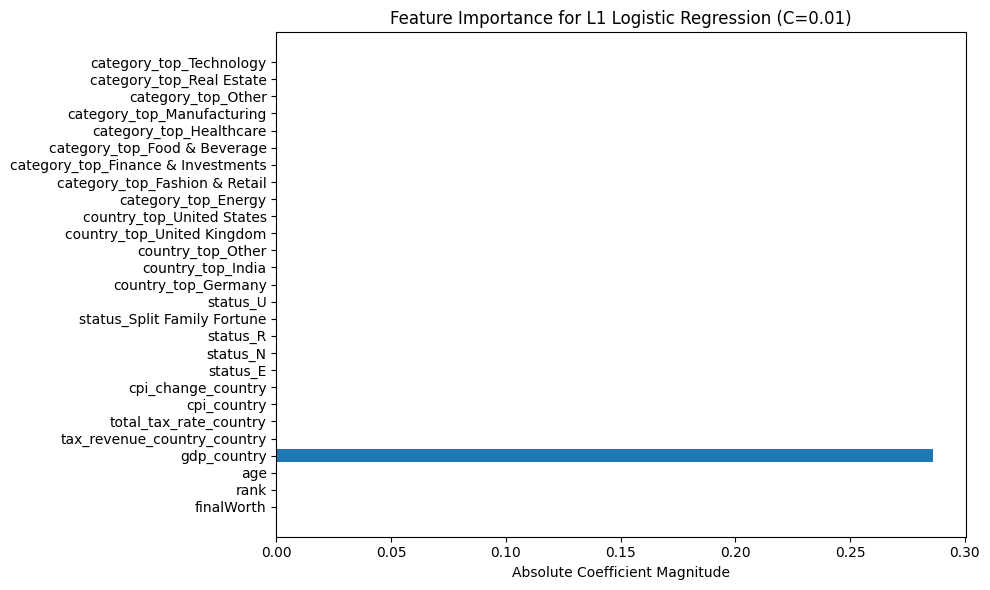

Training accuracy of l1 logreg with C=0.010: 0.69
Test accuracy of l1 logreg with C=0.010: 0.69
Number of features used with C=0.010: 1


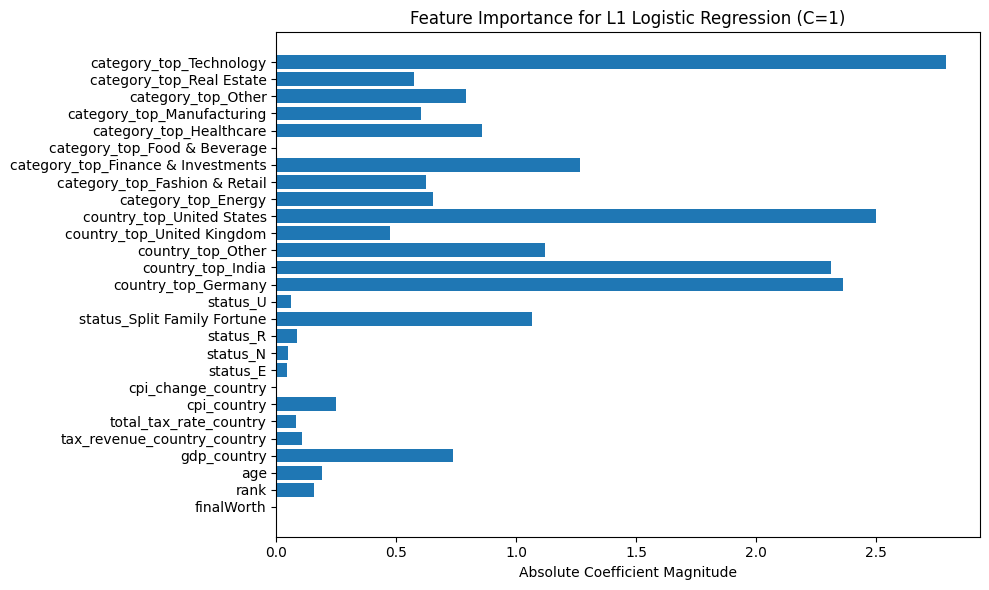

Training accuracy of l1 logreg with C=1.000: 0.75
Test accuracy of l1 logreg with C=1.000: 0.75
Number of features used with C=1.000: 24


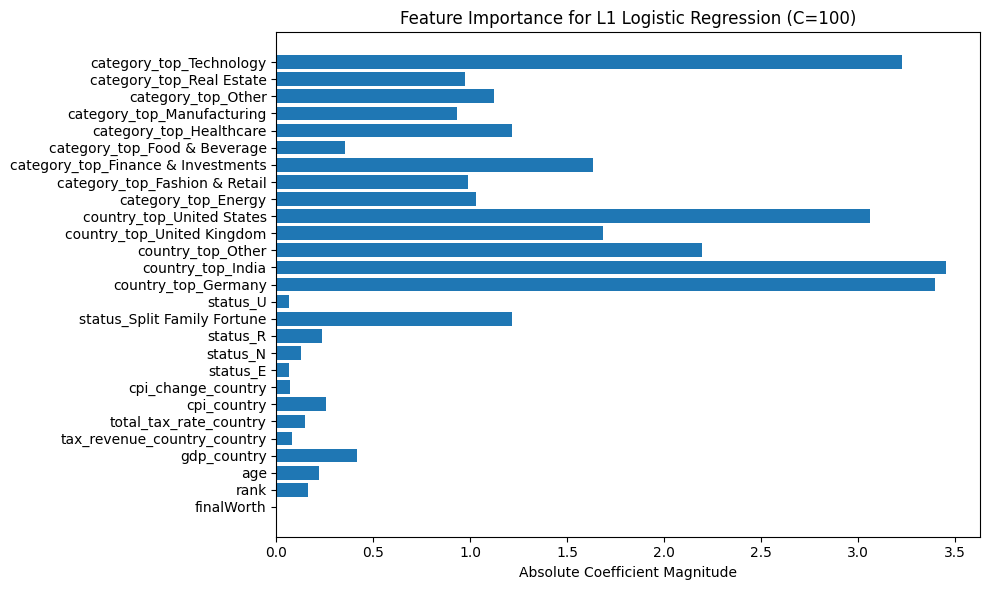

Training accuracy of l1 logreg with C=100.000: 0.75
Test accuracy of l1 logreg with C=100.000: 0.77
Number of features used with C=100.000: 27


In [41]:
import numpy as np
import matplotlib.pyplot as plt

# Define the value of C for Logistic Regression
for C, marker in zip([0.01, 1, 100], ['o', '^', 'v']):
    # Fit Logistic Regression with L1 penalty
    lr_l1 = LogisticRegression(C=C, penalty="l1", solver='liblinear', max_iter=10000).fit(X_train, y_train)

    # Calculate the coefficients (absolute values for feature importance)
    coef = np.abs(lr_l1.coef_.ravel())  # Absolute value for importance

    # Create a bar chart of feature importance
    plt.figure(figsize=(10, 6))
    plt.barh(range(X_train.shape[1]), coef, align='center')
    plt.yticks(range(X_train.shape[1]), X_train.columns)  # Replace with feature names
    plt.xlabel("Absolute Coefficient Magnitude")
    plt.title(f"Feature Importance for L1 Logistic Regression (C={C})")
    plt.tight_layout()
    plt.show()

    # Print additional details
    print(f"Training accuracy of l1 logreg with C={C:.3f}: {lr_l1.score(X_train, y_train):.2f}")
    print(f"Test accuracy of l1 logreg with C={C:.3f}: {lr_l1.score(X_test, y_test):.2f}")
    print(f"Number of features used with C={C:.3f}: {np.sum(lr_l1.coef_ != 0)}")

Earlier we found that the best parameter for Logistic Regression was:

`Best Parameters (Logistic Regression): {'C': 1}`

In this chart, we see that the features that played the most impact were category_top_Technology, country_top_United_Staes, country_top_Germany, and country_top_India. The features with the least impact included finalWorth, cpi_change_country and category_top_Food & Beverage.



Next, we can compare this with the feature importances of the Random Forest and Gradient Boosting models.

In [42]:
feature_importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance (RF)': rf_tuned.feature_importances_,
    'Importance (GB)': gb_tuned.feature_importances_
}).sort_values(by='Importance (RF)', ascending=False)

print("Feature Importance Summary:")
print(feature_importances)

Feature Importance Summary:
                               Feature  Importance (RF)  Importance (GB)
2                                  age         0.103677         0.188304
4          tax_revenue_country_country         0.096661         0.110924
7                   cpi_change_country         0.093900         0.039169
6                          cpi_country         0.085145         0.046353
5               total_tax_rate_country         0.083338         0.084419
3                          gdp_country         0.083015         0.079492
0                           finalWorth         0.078474         0.076910
1                                 rank         0.076115         0.077472
26             category_top_Technology         0.049516         0.059318
15                   country_top_Other         0.029365         0.002083
21        category_top_Food & Beverage         0.024153         0.019836
11         status_Split Family Fortune         0.024151         0.019648
14                   co

We find that Random Forest had age, finalWorth, and rank as the features with the most importance while Gradient Boosting had tax_revenue_country_country, age, gdp_country as the features with the most importance.

## *Conclusion and Recommendations*

This project finds that we can adequately predict whether a billionaire is self made based on their industry of work and country.

Our results particularly suggest that self-made billionaires are most likely associated with industries like technology and finance and the countries the United States, Germany, and India for logistic regression models. Within random forest and gradient boosting models, we find strong feature importance within eceonomic factors like tax revenue, cpi_change, and tax rate.

Future analysis may narrow down their investigation based on their features of interest. I suggest logistic regression for questions connected to characteristic features and random forest/gradient boosting models for question related to economic features and further wealth classification.

With our model performance metrics, however, I would perform deeper hyperparameter tuning for random forest and gradient boosting to optimize performance and generalization better.

Future studies can focus on examining the shifts along time in particular industry dominance and the effects on the rise or decline of self made billionaires. External datasets can provide support on comparisons and conditions including global events and financial crises in certain countries.

Overall, this project highlights economic inequality, as we see that wealth is concentrated in particular industries, countries, and economic factors. We can better support wealth distribution by positioning policymakers and industry leaders to recognize gaps in promoting lesser known industries and underrepresented countries. By doing this, we can assist in the rise of economic mobility and advancement across countries and revitilize the growth of ranging industries and innovation.
